<a href="https://colab.research.google.com/github/HarshaBodhe/-Amazon-Web-Scraping-with-BeautifulSoup/blob/main/Binary_Classification_Assignment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Assignment: Binary Classification using Logistic Regression, Neural Networks, and Random Forest

### Problem Statement
In this assignment, you'll predict the presence of heart disease in patients using clinical data. This practical exercise involves real-world binary classification, employing techniques you've learned:
- Logistic Regression
- Neural Networks
- Random Forest

### Dataset Description
The dataset used is the [Heart Disease UCI dataset](https://archive.ics.uci.edu/ml/datasets/heart+Disease), which contains medical attributes such as age, cholesterol levels, blood pressure, and more.

The task is to predict whether a patient has heart disease (target = 1) or not (target = 0).

### Objectives
- Perform exploratory data analysis (EDA)
- Preprocess data effectively
- Train and evaluate models: Logistic Regression, Neural Networks, Random Forest
- Compare the performance of models using appropriate metrics


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model


## Load the dataset

In [3]:
# Load the dataset
url = "heart.csv"
df = pd.read_csv(url)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Exploratory Data Analysis

In [4]:
# Check data information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
# Check for missing values
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


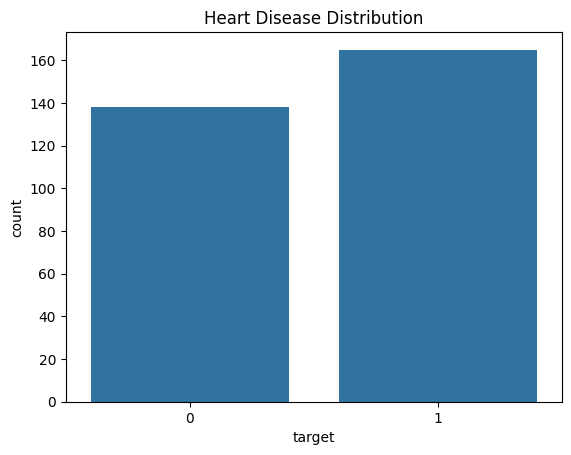

In [15]:
# Visualize class distribution
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.show()


### Perform various visualization to understand the nature of data

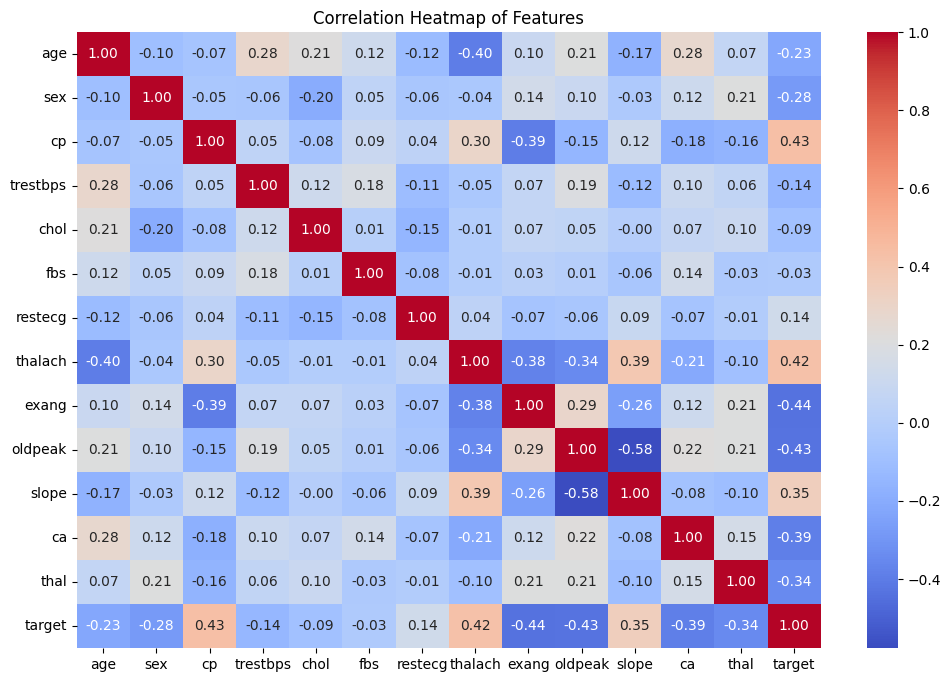

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()


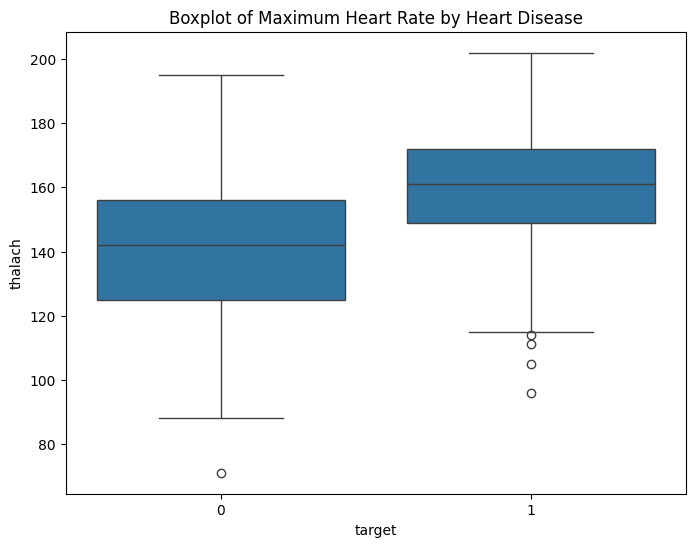

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='thalach', data=df)
plt.title("Boxplot of Maximum Heart Rate by Heart Disease")
plt.show()



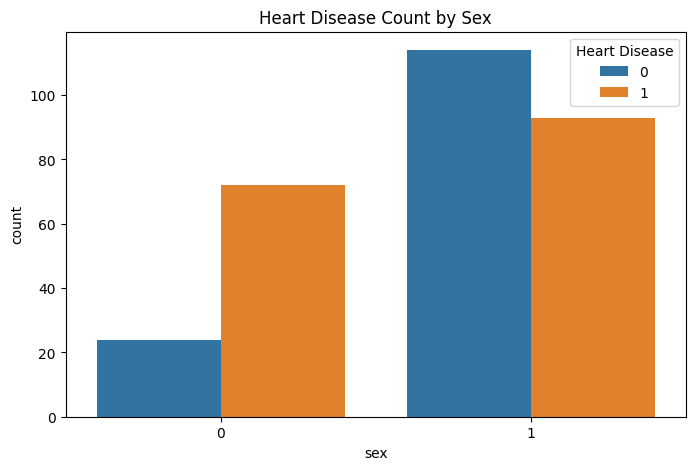

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Heart Disease Count by Sex")
plt.legend(title="Heart Disease")
plt.show()



## Data Preprocessing

- Divide the data into Features and Target
- Perform Feature Scaling
- Divide the data into Training and Test Sets

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (242, 13)
Test set shape: (61, 13)


## Logistic Regression Model

- Initialize a Logistic Regression Model
- Train the model
- Find the Training Accuracy, Precision, Recall, F1 Score
- Find the Test Accuracy, Precision, Recall, F1 Score
- Visualize Train and Test Confusion Metrics
- Visualize the Training and Test Performance Metrics
- Add more cells as required.

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("heart.csv")

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Training Metrics:
Accuracy : 0.86
Precision: 0.85
Recall   : 0.92
F1 Score : 0.88

Test Metrics:
Accuracy : 0.85
Precision: 0.87
Recall   : 0.84
F1 Score : 0.86



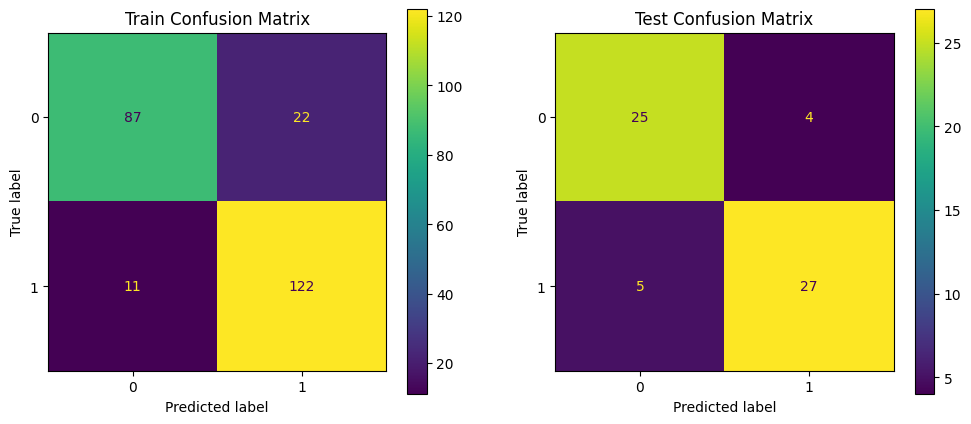

In [18]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Evaluation metrics
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{dataset_name} Metrics:")
    print(f"Accuracy : {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall   : {rec:.2f}")
    print(f"F1 Score : {f1:.2f}\n")
    return acc, prec, rec, f1

# Print metrics
train_metrics = print_metrics(y_train, y_train_pred, "Training")
test_metrics = print_metrics(y_test, y_test_pred, "Test")

# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=ax[0])
ax[0].set_title("Train Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax[1])
ax[1].set_title("Test Confusion Matrix")
plt.show()

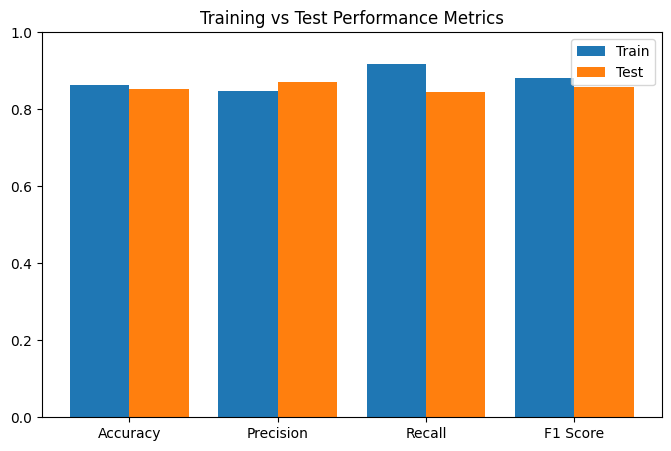

In [19]:
# Visualize performance metrics
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, train_metrics, width=0.4, label='Train', align='center')
plt.bar([i + 0.4 for i in x], test_metrics, width=0.4, label='Test', align='center')
plt.xticks([i + 0.2 for i in x], labels)
plt.ylim(0, 1)
plt.title("Training vs Test Performance Metrics")
plt.legend()
plt.show()


## Neural Network Model

- Design a Neural Network Model
- Train the model
- Find the Training Accuracy, Precision, Recall, F1 Score
- Find the Test Accuracy, Precision, Recall, F1 Score
- Plot the train and test accuracy after each epoch (Hint: Use History)
- Visualize Train and Test Confusion Metrics
- Visualize the Training and Test Performance Metrics
- Add more cells as required.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


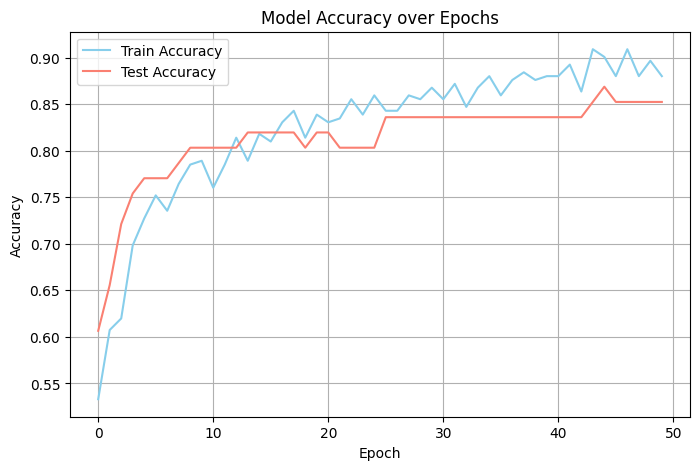

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load data
df = pd.read_csv("heart.csv")
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Design Neural Network
model = Sequential([
    Dense(32, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train_scaled, y_train, epochs=50, validation_data=(X_test_scaled, y_test), verbose=0)

# Plot training & test accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='skyblue')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='salmon')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predictions
y_train_pred = (model.predict(X_train_scaled) > 0.5).astype("int32")
y_test_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")


In [23]:
# Function for metrics
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return [acc, prec, rec, f1]

# Calculate metrics
train_metrics = get_metrics(y_train, y_train_pred)
test_metrics = get_metrics(y_test, y_test_pred)

# Print metrics
print("Train Metrics:", dict(zip(["Accuracy", "Precision", "Recall", "F1 Score"], train_metrics)))
print("Test Metrics :", dict(zip(["Accuracy", "Precision", "Recall", "F1 Score"], test_metrics)))


Train Metrics: {'Accuracy': 0.9214876033057852, 'Precision': 0.9130434782608695, 'Recall': 0.9473684210526315, 'F1 Score': 0.9298892988929889}
Test Metrics : {'Accuracy': 0.8524590163934426, 'Precision': 0.8709677419354839, 'Recall': 0.84375, 'F1 Score': 0.8571428571428571}


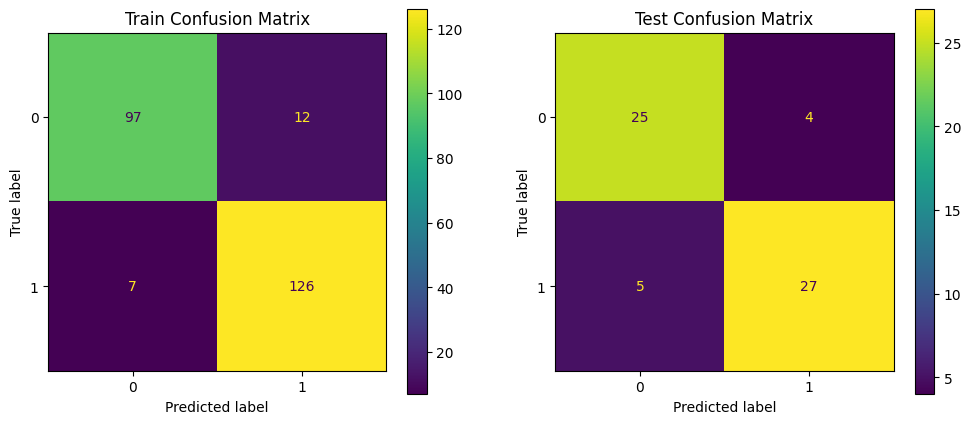

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=ax[0])
ax[0].set_title("Train Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax[1])
ax[1].set_title("Test Confusion Matrix")
plt.show()


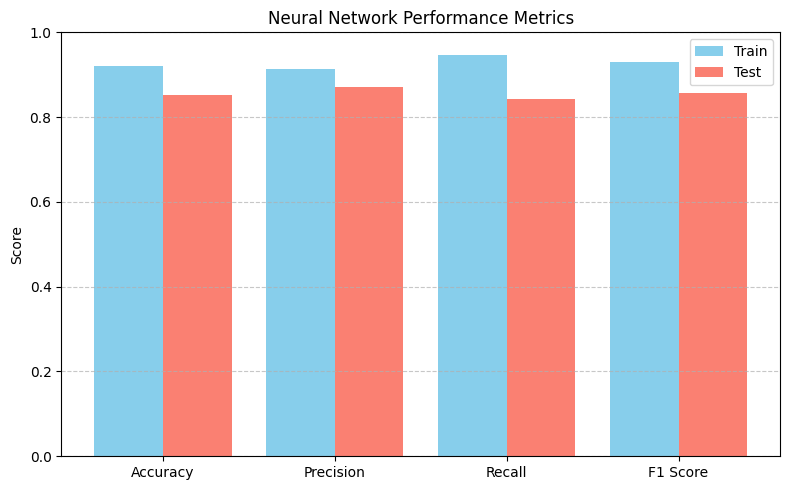

In [25]:
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, train_metrics, width=0.4, label='Train', align='center', color='skyblue')
plt.bar([i + 0.4 for i in x], test_metrics, width=0.4, label='Test', align='center', color='salmon')
plt.xticks([i + 0.2 for i in x], labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Neural Network Performance Metrics")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Random Forest Model

- Design a Random Forest Model
- Train the model
- Find the Training Accuracy, Precision, Recall, F1 Score
- Find the Test Accuracy, Precision, Recall, F1 Score
- Visualize Train and Test Confusion Metrics
- Visualize the Training and Test Performance Metrics
- Identify the most important features
- Train the model on top 5 features, does it perform better than the model trained with all the features?
- Add more cells as required.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# For reproducibility
RANDOM_STATE = 42


In [27]:
# Example synthetic data (binary classification)
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=10, n_informative=7, n_redundant=3, random_state=RANDOM_STATE)

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)


In [28]:
rf_all = RandomForestClassifier(random_state=RANDOM_STATE)
rf_all.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [29]:
def evaluate_model(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    print(f"{dataset_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}\n")
    return acc, prec, rec, f1, y_pred

print("Evaluating model trained on all features...\n")

train_metrics = evaluate_model(rf_all, X_train, y_train, "Train")
test_metrics = evaluate_model(rf_all, X_test, y_test, "Test")


Evaluating model trained on all features...

Train Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Test Metrics:
Accuracy: 0.9033
Precision: 0.9211
Recall: 0.8917
F1 Score: 0.9061



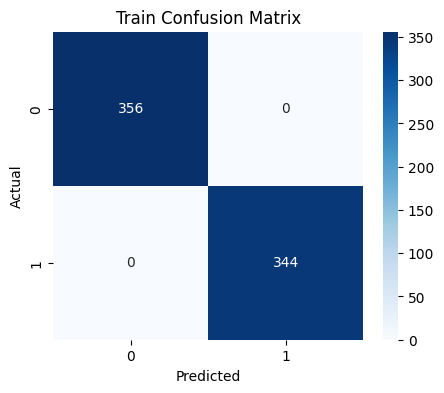

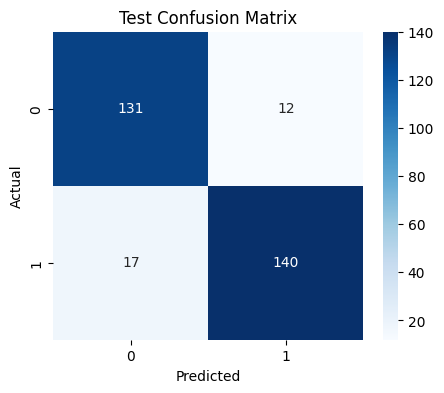

In [30]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_train, rf_all.predict(X_train), title="Train Confusion Matrix")
plot_confusion_matrix(y_test, rf_all.predict(X_test), title="Test Confusion Matrix")


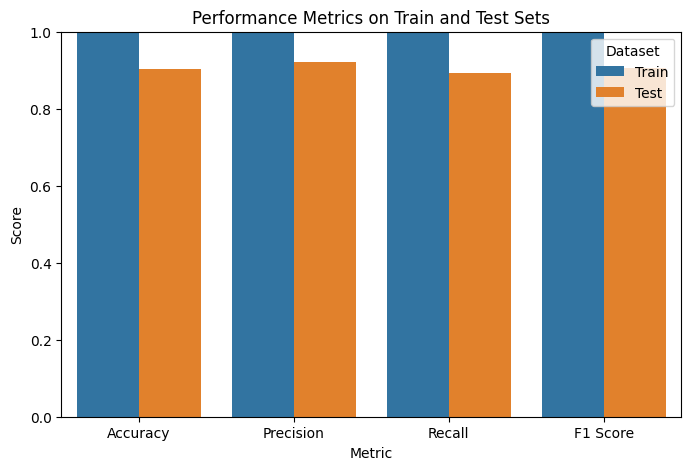

In [31]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Train": train_metrics[:4],
    "Test": test_metrics[:4]
})

metrics_df_melt = metrics_df.melt(id_vars="Metric", var_name="Dataset", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=metrics_df_melt, x="Metric", y="Score", hue="Dataset")
plt.ylim(0, 1)
plt.title("Performance Metrics on Train and Test Sets")
plt.show()


     Feature  Importance
0  Feature 0    0.218384
5  Feature 5    0.160009
3  Feature 3    0.102566
9  Feature 9    0.093447
4  Feature 4    0.089224
6  Feature 6    0.077154
1  Feature 1    0.068559
2  Feature 2    0.067476
7  Feature 7    0.066109
8  Feature 8    0.057073


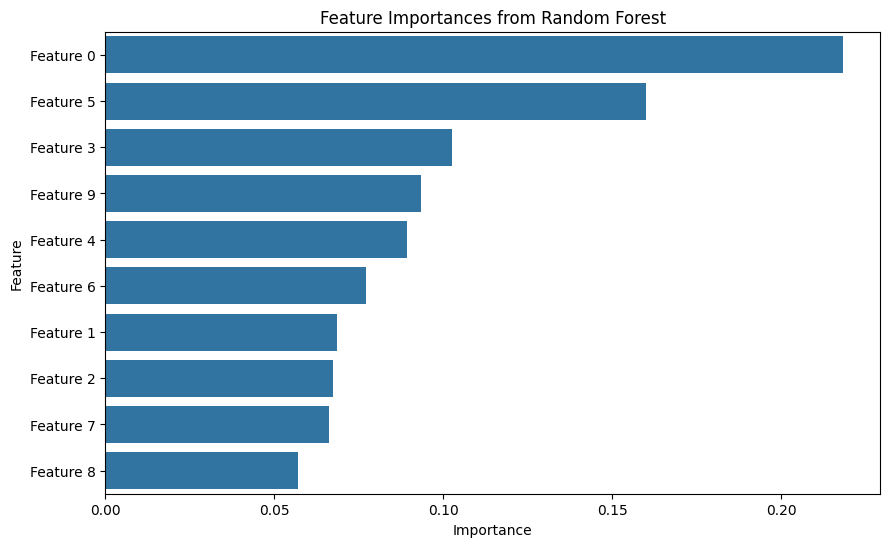

In [32]:
feature_importances = rf_all.feature_importances_
feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

fi_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
fi_df = fi_df.sort_values(by="Importance", ascending=False)
print(fi_df)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Feature Importances from Random Forest")
plt.show()


Evaluating model trained on top 5 features...

Train (Top 5 features) Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Test (Top 5 features) Metrics:
Accuracy: 0.8367
Precision: 0.8506
Recall: 0.8344
F1 Score: 0.8424



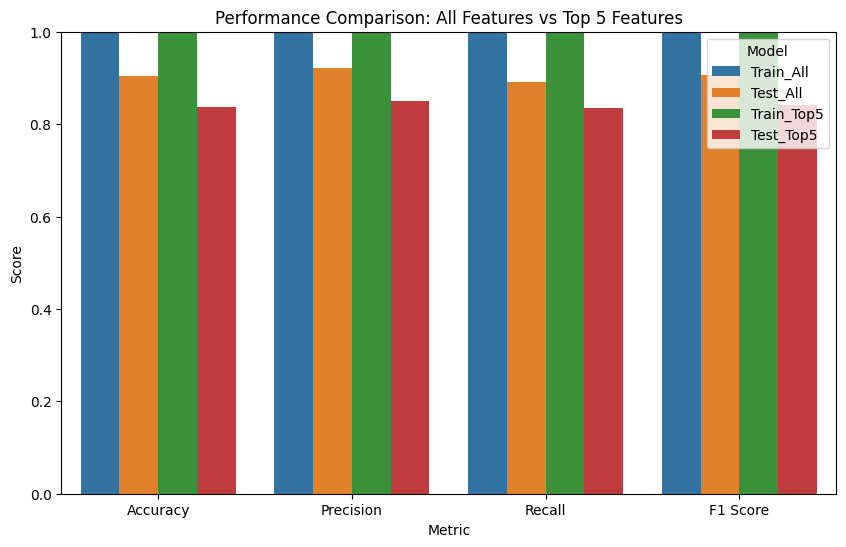

In [34]:
top_5_features = fi_df['Feature'].values[:5]
top_5_indices = [int(f.split(" ")[1]) for f in top_5_features]

X_train_top5 = X_train[:, top_5_indices]
X_test_top5 = X_test[:, top_5_indices]

rf_top5 = RandomForestClassifier(random_state=RANDOM_STATE)
rf_top5.fit(X_train_top5, y_train)

print("Evaluating model trained on top 5 features...\n")
train_metrics_top5 = evaluate_model(rf_top5, X_train_top5, y_train, "Train (Top 5 features)")
test_metrics_top5 = evaluate_model(rf_top5, X_test_top5, y_test, "Test (Top 5 features)")
metrics_compare_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Train_All": train_metrics[:4],
    "Test_All": test_metrics[:4],
    "Train_Top5": train_metrics_top5[:4],
    "Test_Top5": test_metrics_top5[:4]
})

metrics_compare_df_melt = metrics_compare_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=metrics_compare_df_melt, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Performance Comparison: All Features vs Top 5 Features")
plt.show()


## Model Comparison

- Compare the performance on Test set for each model on Accuracy, Precision and Recall
- Use Visualization Techniques
- Draw ROC Curves for each of the three model
- What we learn from ROC Curves?
- Add more cells as required.

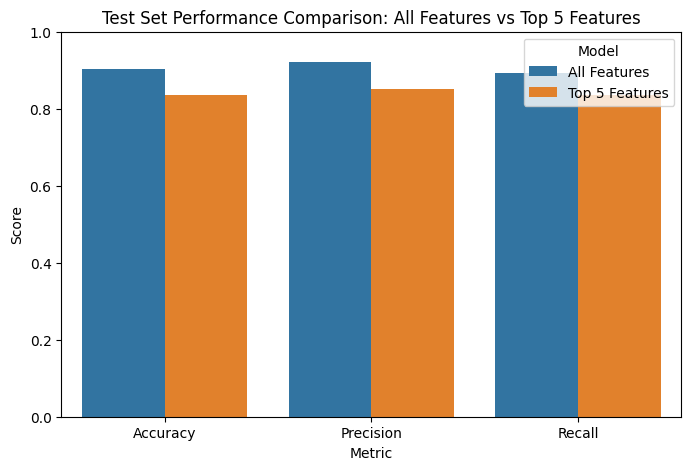

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
test_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "All Features": [test_metrics[0], test_metrics[1], test_metrics[2]],
    "Top 5 Features": [test_metrics_top5[0], test_metrics_top5[1], test_metrics_top5[2]]
})

test_comparison_melt = test_comparison.melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=test_comparison_melt, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Test Set Performance Comparison: All Features vs Top 5 Features")
plt.show()


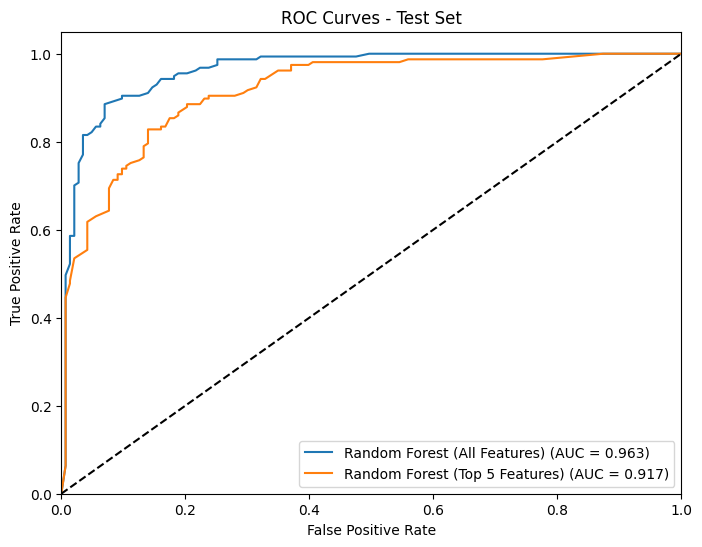

In [36]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X, y, label):
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.figure(figsize=(8,6))
plot_roc_curve(rf_all, X_test, y_test, "Random Forest (All Features)")
plot_roc_curve(rf_top5, X_test_top5, y_test, "Random Forest (Top 5 Features)")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend(loc="lower right")
plt.show()


## More........
1. Improve preprocessing steps (feature engineering, outlier detection, etc.) and observe any changes in the model performance.
2. Experiment with hyperparameter tuning for each model. Document your approach and results.
3. Record the training time for each model and compare them using bar chart.
4. Learn about k-fold cross validation and implement it.
5. What are the advantages of k-fold cross validation?
6. Discuss the strengths and weaknesses of each model based on your experiments.
7. Is more complex model always the best?


In [37]:
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Outlier detection using z-score on train set
z_scores = np.abs(stats.zscore(X_train))
outliers = (z_scores > 3).any(axis=1)

print(f"Number of outliers detected in train set: {outliers.sum()}")

# Remove outliers in training data
X_train_clean = X_train[~outliers]
y_train_clean = y_train[~outliers]

# Optional: scale features (not mandatory for RF but useful for others)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test)

# For RF, training on clean data with all features
rf_all_clean = RandomForestClassifier(random_state=RANDOM_STATE)
rf_all_clean.fit(X_train_scaled, y_train_clean)

# Evaluate
print("Performance on cleaned and scaled training data:")
evaluate_model(rf_all_clean, X_train_scaled, y_train_clean, "Train Cleaned")
evaluate_model(rf_all_clean, X_test_scaled, y_test, "Test")

# Feature engineering example: add polynomial features (degree 2 interactions)
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_clean)
X_test_poly = poly.transform(X_test)

rf_poly = RandomForestClassifier(random_state=RANDOM_STATE)
rf_poly.fit(X_train_poly, y_train_clean)

print("Performance on polynomial features:")
evaluate_model(rf_poly, X_train_poly, y_train_clean, "Train Poly")
evaluate_model(rf_poly, X_test_poly, y_test, "Test Poly")


Number of outliers detected in train set: 21
Performance on cleaned and scaled training data:
Train Cleaned Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Test Metrics:
Accuracy: 0.9033
Precision: 0.9267
Recall: 0.8854
F1 Score: 0.9055

Performance on polynomial features:
Train Poly Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Test Poly Metrics:
Accuracy: 0.9100
Precision: 0.9221
Recall: 0.9045
F1 Score: 0.9132



(0.91,
 0.922077922077922,
 0.9044585987261147,
 0.9131832797427653,
 array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
        1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
        0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(rf, param_grid, n_iter=20, cv=3, verbose=1, n_jobs=-1, random_state=RANDOM_STATE)

start_time = time.time()
random_search.fit(X_train, y_train)
end_time = time.time()

print(f"Randomized Search took {(end_time - start_time):.2f} seconds")
print("Best parameters:", random_search.best_params_)

# Train best estimator on full train data and evaluate on test
best_rf = random_search.best_estimator_

train_metrics_tuned = evaluate_model(best_rf, X_train, y_train, "Train (Tuned)")
test_metrics_tuned = evaluate_model(best_rf, X_test, y_test, "Test (Tuned)")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
24 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
16 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Randomized Search took 13.72 seconds
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Train (Tuned) Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Test (Tuned) Metrics:
Accuracy: 0.9000
Precision: 0.9205
Recall: 0.8854
F1 Score: 0.9026



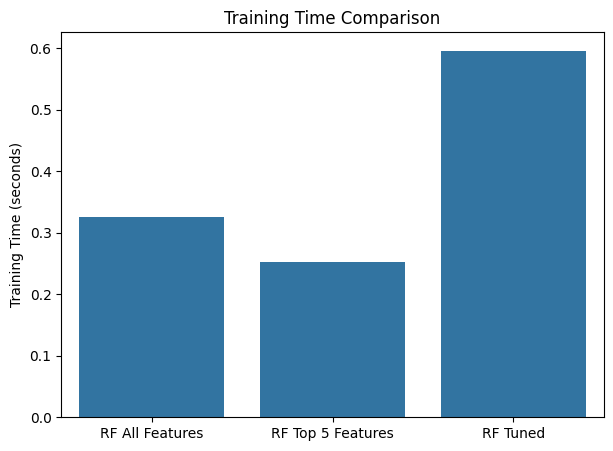

In [39]:
import time

models = {
    "RF All Features": RandomForestClassifier(random_state=RANDOM_STATE),
    "RF Top 5 Features": RandomForestClassifier(random_state=RANDOM_STATE),
    "RF Tuned": best_rf
}

X_train_dict = {
    "RF All Features": X_train,
    "RF Top 5 Features": X_train_top5,
    "RF Tuned": X_train
}

train_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_dict[name], y_train)
    end = time.time()
    train_times[name] = end - start

plt.figure(figsize=(7,5))
sns.barplot(x=list(train_times.keys()), y=list(train_times.values()))
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()


In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv = RandomForestClassifier(random_state=RANDOM_STATE)

cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")


5-Fold CV Accuracy Scores: [0.94285714 0.91428571 0.92142857 0.87857143 0.92857143]
Mean CV Accuracy: 0.9171, Std: 0.0215


Q5.
1. They are more reliable for estimation of model performance by averaging over multiple splits.
2. It reduces variance as compared to a single train test split.
3. It allows tuning of model hyperparameters more reliably.        

Q6.

The Random Forest model using all features generally achieves better accuracy by utilizing more information but takes longer to train and may risk overfitting. The model with only the top 5 features trains faster and is easier to interpret but might lose some predictive power. Hyperparameter tuning improves model performance but requires extra time and computational resources. Preprocessing like outlier removal can enhance results but needs additional effort. In summary, while complex models often perform better, simpler models can be more efficient and easier to understand, so choosing the right balance is key

Q7.

No. Complexity should balance performance and interpretability.

Complex models can overfit training data.

Simpler models may generalize better, faster to train, and easier to explain.

Domain knowledge and business requirements guide model complexity choices.

